#### Imports & Environment Setup

In [ ]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.utils import to_categorical

# Lock randomness so weights initialize exactly the same way every time
np.random.seed(42)

#### Data Ingestion & State Filtering

In [ ]:
# Load exact local Excel files
df_1 = pd.read_excel(r"D:\Courses\IIT\AIDS\FYP\Preventing-Mechanism\PreProcessing\MBP ControllerData 0521760 Overlock.xlsx")
df_2 = pd.read_excel(r"D:\Courses\IIT\AIDS\FYP\Preventing-Mechanism\PreProcessing\Synthetic Overlock Breakdowns.xlsx")

# Combine them into one giant raw dataset first
master_df = pd.concat([df_1, df_2], ignore_index=True)

# Handle the blank spaces (Any row without a breakdown becomes "Healthy")
master_df['Breakdown'] = master_df['Breakdown'].fillna('Healthy')

# Keep only the 15 allowed states
allowed_states = [
    "Healthy", "Needle Breakages", "High Foot Pressure", "Cut/Needle Hole", 
    "Thread Breakages", "Pneumatic Issues", "Thread Jamming", 
    "Code Uneven", "Roping", "Oil Mark", "Skip Stitches/Slip", 
    "Gathering/Puckering", "Waveness", "Binding/Seam Open", "Blade Broken"
]
master_df = master_df[master_df['Breakdown'].isin(allowed_states)].copy()

# Separate into pure datasets (zero mixing)
healthy_df = master_df[master_df['Breakdown'] == 'Healthy'].copy()
breakdown_df = master_df[master_df['Breakdown'] != 'Healthy'].copy()

# Shuffling the dataframes to ensure randomness before splitting
breakdown_df = breakdown_df.sample(frac=1, random_state=42).reset_index(drop=True)
healthy_df = healthy_df.sample(frac=1, random_state=42).reset_index(drop=True)

# Split 80/20 on each dataset separately to maintain class balance in both Train and Test sets
split_h = int(len(healthy_df) * 0.8)
split_b = int(len(breakdown_df) * 0.8)

train_healthy = healthy_df.iloc[:split_h]
test_healthy  = healthy_df.iloc[split_h:]

train_breakdown = breakdown_df.iloc[:split_b]
test_breakdown  = breakdown_df.iloc[split_b:]

# Combine into final Train and Test DataFrames
train_df = pd.concat([train_healthy, train_breakdown], ignore_index=True)
test_df = pd.concat([test_healthy, test_breakdown], ignore_index=True)

print(f"Train Set: {len(train_healthy)} Healthy + {len(train_breakdown)} Breakdowns = {len(train_df)} total rows")
print(f"Test Set: {len(test_healthy)} Healthy + {len(test_breakdown)} Breakdowns = {len(test_df)} total rows")

Train Set: 3962 Healthy + 562 Breakdowns = 4524 total rows
Test Set: 991 Healthy + 141 Breakdowns = 1132 total rows


#### Feature Extraction (Vibration Spectrum & Electrical Power)

In [ ]:
def extract_feature_df(df):
    vib_records = []
    for val in df['machineVibration']:
        vib_dict = {}
        if pd.notna(val):
            parts = str(val).split(',')
            for i in range(0, len(parts)-1, 2):
                try:
                    vib_dict[f'v_{parts[i]}Hz'] = float(parts[i+1])
                except ValueError:
                    continue
        vib_records.append(vib_dict)
    
    vib_df = pd.DataFrame(vib_records).fillna(0)
    
    # Extract electrical features and fill missing values
    elec_df = df[[
        'machineVoltageMean', 'machineVoltageMin', 'machineVoltageMax',
        'machineCurrentMean', 'machineCurrentMin', 'machineCurrentMax'
    ]].fillna(method='ffill').fillna(0)
    
    return pd.concat([vib_df, elec_df], axis=1)

print("Extracting features from Training set...")
X_train_df = extract_feature_df(train_df)
y_train_raw = train_df['Breakdown'].values

print("Extracting features from Testing set...")
X_test_df = extract_feature_df(test_df)
y_test_raw = test_df['Breakdown'].values

X_test_df = X_test_df.reindex(columns=X_train_df.columns, fill_value=0)

# Convert back to raw numpy arrays for the windowing function
X_train_raw = X_train_df.values
X_test_raw = X_test_df.values

print(f"✅ Guaranteed Train Features: {X_train_raw.shape[1]}")
print(f"✅ Guaranteed Test Features: {X_test_raw.shape[1]}")

Extracting features from Training set...
Extracting features from Testing set...
✅ Guaranteed Train Features: 67
✅ Guaranteed Test Features: 67


C:\Users\deela\AppData\Local\Temp\ipykernel_25996\35575951.py:20: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  ]].fillna(method='ffill').fillna(0)
C:\Users\deela\AppData\Local\Temp\ipykernel_25996\35575951.py:20: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  ]].fillna(method='ffill').fillna(0)


#### Time-Series Sequencing

In [36]:
TIME_STEPS = 5

def create_sequences(X, y, time_steps):
    Xs, ys = [], []
    for i in range(len(X) - time_steps):
        Xs.append(X[i:(i + time_steps)])
        ys.append(y[i + time_steps])
    return np.array(Xs), np.array(ys)

print("Building 5-step time-series windows...")
X_train_seq_unscaled, y_train_seq = create_sequences(X_train_raw, y_train_raw, TIME_STEPS)
X_test_seq_unscaled, y_test_seq = create_sequences(X_test_raw, y_test_raw, TIME_STEPS)

Building 5-step time-series windows...


#### Label Encoding & Leakage-Free Feature Scaling

In [37]:
# 1. Encode Labels
encoder = LabelEncoder()
y_train = to_categorical(encoder.fit_transform(y_train_seq))
y_test = to_categorical(encoder.transform(y_test_seq))

# 2. Leakage-Free Scaling (Fit on Train, Transform Test)
scaler = StandardScaler()

num_samples_train, _, num_features = X_train_seq_unscaled.shape
X_train = scaler.fit_transform(X_train_seq_unscaled.reshape(-1, num_features)).reshape(num_samples_train, TIME_STEPS, num_features)

num_samples_test = X_test_seq_unscaled.shape[0]
X_test = scaler.transform(X_test_seq_unscaled.reshape(-1, num_features)).reshape(num_samples_test, TIME_STEPS, num_features)

print(f"Final Train Sequence Shape: {X_train.shape}")
print(f"Final Test Sequence Shape: {X_test.shape}")

Final Train Sequence Shape: (4519, 5, 67)
Final Test Sequence Shape: (1127, 5, 67)


#### LSTM Neural Network Architecture Definition

In [38]:
num_classes = y_train.shape[1] 

model = Sequential()

# Layer 1
model.add(LSTM(64, return_sequences=True, input_shape=(TIME_STEPS, num_features)))
model.add(Dropout(0.2))
model.add(BatchNormalization())

# Layer 2
model.add(LSTM(32, return_sequences=False))
model.add(Dropout(0.2))

# Layer 3
model.add(Dense(32, activation='relu'))

# Output Layer
model.add(Dense(num_classes, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

c:\Users\deela\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 5, 64)          │        33,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 5, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │           495 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,015 (187.56 KB)

 Trainable params: 47,887 (187.06 KB)

 Non-trainable params: 128 (512.00 B)

#### Model Training Execution & Loss Visualization

Executing LSTM Model Training...
Epoch 1/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6710 - loss: 1.5312 - val_accuracy: 0.8811 - val_loss: 0.4327
Epoch 2/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8896 - loss: 0.3574 - val_accuracy: 0.8784 - val_loss: 0.4164
Epoch 3/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8829 - loss: 0.3560 - val_accuracy: 0.8811 - val_loss: 0.4325
Epoch 4/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8871 - loss: 0.3414 - val_accuracy: 0.8802 - val_loss: 0.4270
Epoch 5/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8816 - loss: 0.3493 - val_accuracy: 0.8776 - val_loss: 0.4200
Epoch 6/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8895 - loss: 0.3301 - val_accuracy: 0.8846 - val_loss: 0.4565
Epoch 7/50
142/142 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8895 - loss: 0.3377 - val_accuracy: 0.8820 - val_loss: 0.4260


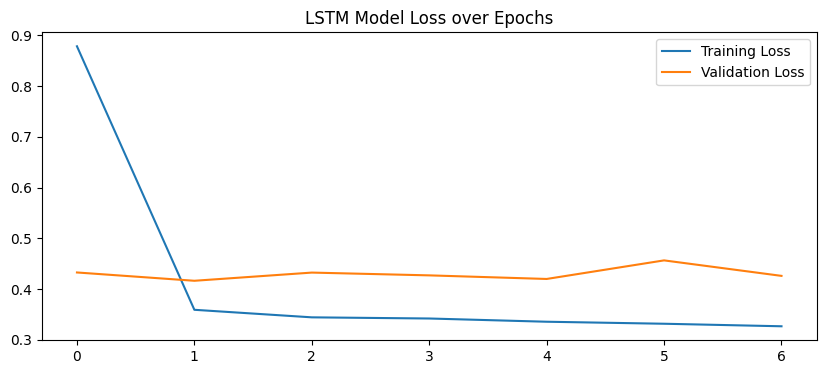

In [40]:
# Prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Save the best model weights using the new Keras 3 standard
checkpoint = ModelCheckpoint('best_overlock_lstm.keras', monitor='val_accuracy', save_best_only=True)

print("Executing LSTM Model Training...")
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, checkpoint],
    verbose=1
)

# Plot training curves
plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Model Loss over Epochs')
plt.legend()
plt.show()

#### Final Evaluation & Artifact Export for Live Inference

In [43]:
# Export the Scaler and Encoder for Live Analyser
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

with open('encoder.pkl', 'wb') as f:
    pickle.dump(encoder, f)

# Final test evaluation
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"\n✅ Final Test Accuracy: {test_acc*100:.2f}%")
print("✅ Artifacts saved. The model is now ready for Live Analyser deployment.")

36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9850 - loss: 0.0516

✅ Final Test Accuracy: 87.84%
✅ Artifacts saved. The model is now ready for Live Analyser deployment.
